# ECF4 - Fake News

In [4]:
# Imports
import warnings
from pathlib import Path
from collections import Counter
from copy import deepcopy
import re
import time
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import spacy
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import joblib


def ensure_stopwords_downloaded():
    try:
        nltk.data.find("corpora/stopwords")
    except LookupError:
        nltk.download("stopwords")


ensure_stopwords_downloaded()

warnings.filterwarnings("ignore")

In [5]:
# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()

In [6]:
# Chemins
PROJECT_DIR = Path("../").resolve()
DATA_DIR = PROJECT_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
DATA_FILE = DATA_DIR / "fake_or_real_news.csv"
DATA_CLEAN_FILE = DATA_DIR / "titles_clean.csv"

FIGURE_DIR = PROJECT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MODELS_DIR = PROJECT_DIR / "models"
TF_IDF_VECTORIZER_FILE = MODELS_DIR / "tf_idf_vectorizer.pkl"
MODEL_DENSE_FILE = MODELS_DIR / "model_dense.keras"
MODEL_BIDIRECTIONAL_LSTM_FILE = MODELS_DIR / "model_bidirectional_lstm.keras"

In [7]:
# Configurations des graphiques
sns.set_theme(
    style="whitegrid",
    palette="colorblind",
    context="notebook",
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "Arial",
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 13,
        "axes.labelweight": "medium",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "lines.linewidth": 2.2,
        "lines.markersize": 7,
        "legend.fontsize": 11,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "grid.linestyle": ":",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.6,
    }
)

PALETTE = sns.color_palette("colorblind")

## Partie 1 — Chargement et exploration

### 1.1 Chargement et constitution du corpus de titres

In [8]:
def normalize_text(text):
    if text is None:
        return ""

    text = unicodedata.normalize("NFKC", str(text))
    text = text.encode("ascii", "ignore").decode("ascii")
    text = text.encode("utf-8", "ignore").decode("utf-8")
    return text


def convert_label(label_str: str) -> int:
    if label_str.lower() == "fake":
        return 0
    elif label_str.lower() == "real":
        return 1
    else:
        return None


def load_titles(filepath: Path) -> pd.DataFrame:
    if not filepath.exists():
        raise FileNotFoundError(f"Fichier introuvable: path={str(filepath)}")

    df = pd.read_csv(filepath, encoding="utf-8", encoding_errors="ignore")
    length_df = len(df)
    print(
        f"Dimensions du jeu de données chargé : {df.shape[0]} lignes et {df.shape[1]} colonnes"
    )

    df = df[["title", "label"]]
    df = df.rename(columns={"title": "text"})
    df["label"] = df["label"].apply(convert_label)
    df["text"] = df["text"].apply(normalize_text)
    df = df.dropna()
    mask = (
        (df["text"].str.strip() != "")
        & (df["text"].str.strip().str.lower() != "null")
        & (df["text"].str.strip().str.lower() != "none")
    )
    df = df[mask]
    length_df_processed = len(df)
    print(
        f"Dimensions du jeu de données après traitement : {df.shape[0]} lignes et {df.shape[1]} colonnes"
    )
    print(f"Nombre de lignes supprimées : {length_df - length_df_processed}")

    df.to_csv(DATA_CLEAN_FILE, index=False)
    return df


df = load_titles(DATA_FILE)
df.head()

Dimensions du jeu de données chargé : 6335 lignes et 4 colonnes
Dimensions du jeu de données après traitement : 6335 lignes et 2 colonnes
Nombre de lignes supprimées : 0


,text,label
0,You Can Smell Hillarys Fear,0
1,Watch The Exact Moment Paul Ryan Committed Pol...,0
2,Kerry to go to Paris in gesture of sympathy,1
3,Bernie supporters on Twitter erupt in anger ag...,0
4,The Battle of New York: Why This Primary Matters,1


La fonction `normalize_text` résoud des problèmes d'encodage rencontrés lors du chargement des données.

### 1.2 Analyse exploratoire

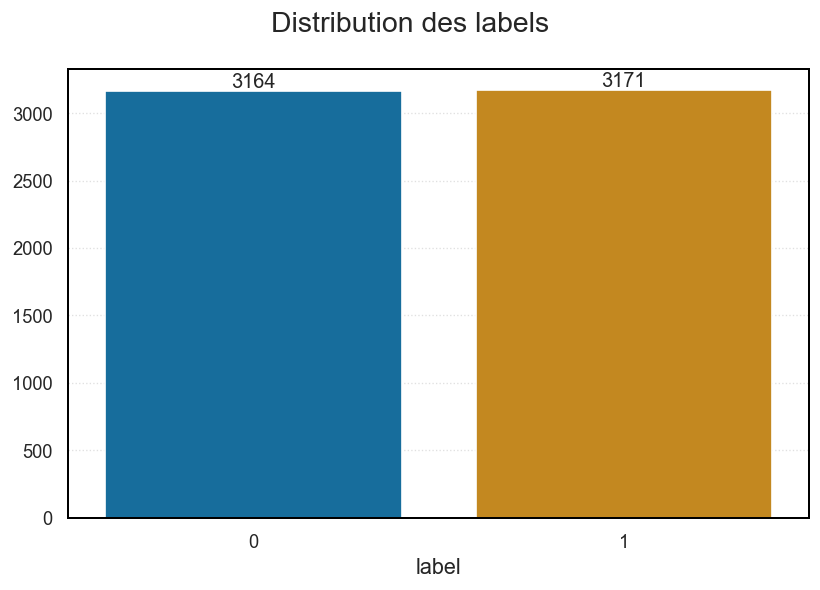

In [9]:
def create_barplot(
    ax: plt.Axes, df: pd.DataFrame, column: str, rotation: int = 0
) -> None:
    value_counts = df[column].value_counts()

    barplot = sns.barplot(
        x=value_counts.index,
        y=value_counts.values,
        palette=PALETTE,
        hue=value_counts.index,
        legend=False,
        ax=ax,
    )

    for container in barplot.containers:
        barplot.bar_label(container)

    if rotation:
        ax.tick_params(axis="x", rotation=rotation)


fig, ax = plt.subplots(1, 1, figsize=(7, 5))

fig.suptitle("Distribution des labels", fontsize=17)

create_barplot(ax=ax, df=df, column="label", rotation=0)

plt.tight_layout()
plt.savefig((FIGURE_DIR / "01_label_distrubution.png").as_posix())
plt.show()

Les classes sont équilibrée, aucune stratégie de rééquilibrage n'est à prévoir. Si les classes avaient été déséquilibrées, on aurait pu mettre en place une stratégie d'oversampling consistant à ajouter des données dans la classe minoritaire. Ces nouvelles données pouvant être artificielles ou une duplication des données existantes. Un autre stratégie possible consiste à pondérer la classes minoritaire avec un poid plus important lors de la phase d'entraînement d'un modèle de sorte qu'un classement érroné d'une classe minoritaire soit plus lourdement pénalisé.

In [10]:
df_eda = df.copy()
df_eda["tokens"] = df_eda["text"].str.split()
df_eda["length"] = df_eda["tokens"].apply(lambda list_tokens: len(list_tokens))

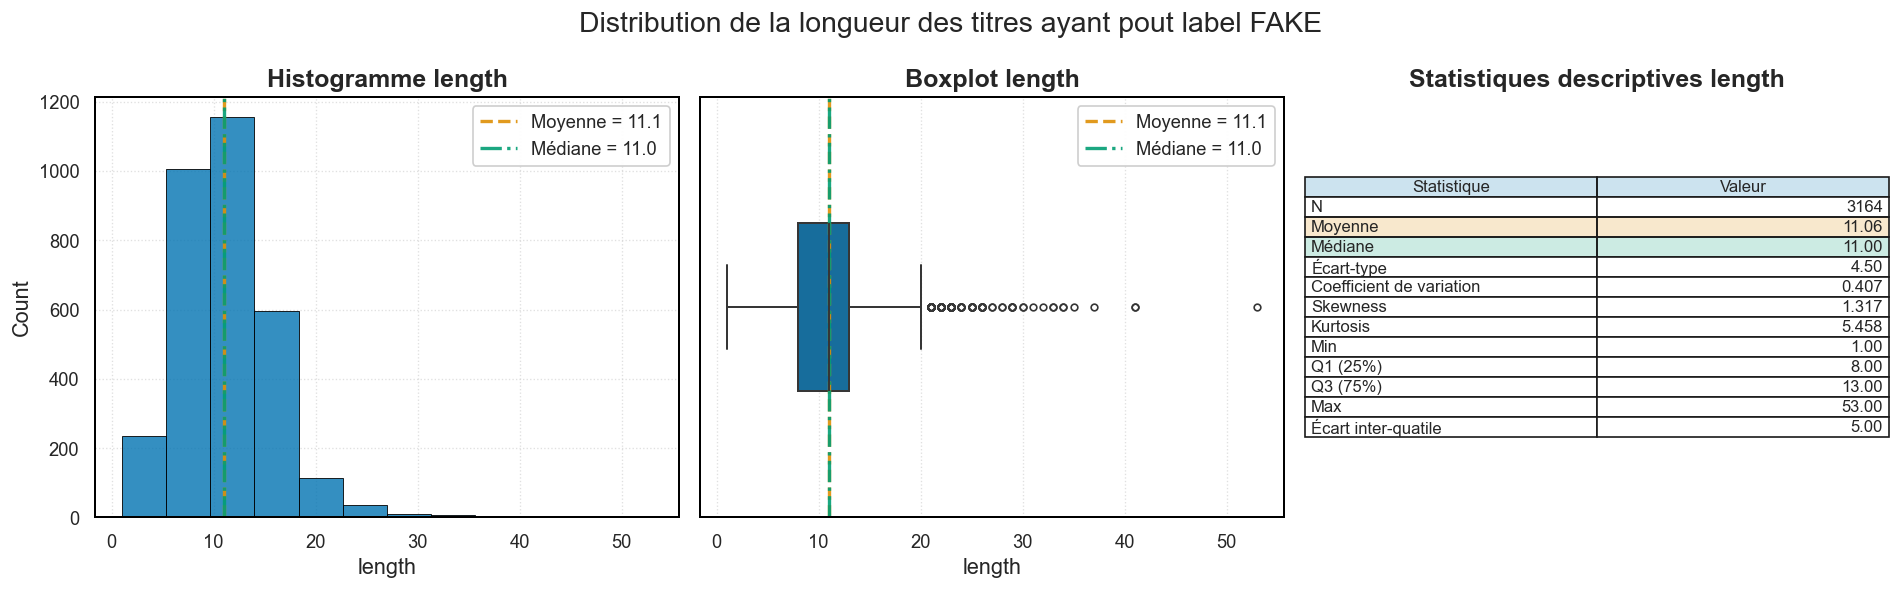

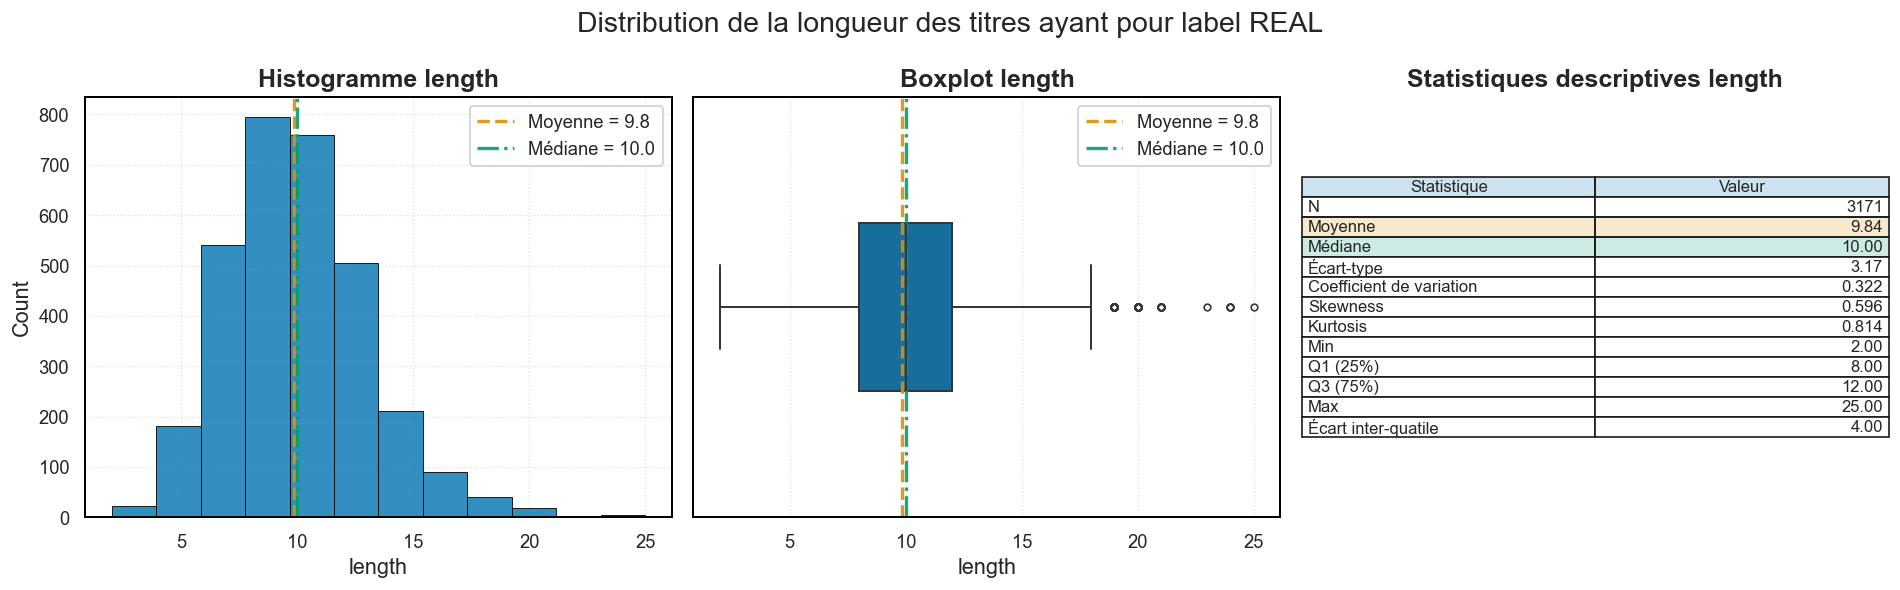

In [11]:
def create_histplot(ax: plt.Axes, df: pd.DataFrame, column: str) -> None:
    values = df[column].dropna()

    sns.histplot(
        x=values,
        bins=int(1 + np.log2(len(values))),
        color=PALETTE[0],
        edgecolor="black",
        linewidth=0.5,
        alpha=0.8,
        ax=ax,
    )

    mean_column = values.mean()
    median_column = values.median()

    ax.axvline(
        mean_column,
        color=PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_column:.1f}",
    )

    ax.axvline(
        median_column,
        color=PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_column:.1f}",
    )

    ax.set_title(f"Histogramme {column}")
    ax.legend(frameon=True)


def create_boxplot(ax: plt.Axes, df: pd.DataFrame, column: str) -> None:
    values = df[column].dropna()

    sns.boxplot(
        x=values,
        ax=ax,
        color=PALETTE[0],
        width=0.4,
        fliersize=4,
        linewidth=1.2,
    )

    mean_val = values.mean()
    median_val = values.median()

    ax.axvline(
        mean_val,
        color=PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_val:.1f}",
    )

    ax.axvline(
        median_val,
        color=PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_val:.1f}",
    )

    ax.set_title(f"Boxplot {column}")
    ax.legend(frameon=True)


def create_stats_panel(ax: plt.Axes, df: pd.DataFrame, column: str) -> None:
    values = df[column].dropna()

    mean_val = values.mean()
    std_val = values.std()
    cv = std_val / mean_val if mean_val != 0 else np.nan
    skew = values.skew()
    kurt = values.kurtosis()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    stats_data = [
        ["N", f"{len(values)}"],
        ["Moyenne", f"{mean_val:.2f}"],
        ["Médiane", f"{values.median():.2f}"],
        ["Écart-type", f"{std_val:.2f}"],
        ["Coefficient de variation", f"{cv:.3f}"],
        ["Skewness", f"{skew:.3f}"],
        ["Kurtosis", f"{kurt:.3f}"],
        ["Min", f"{values.min():.2f}"],
        ["Q1 (25%)", f"{q1:.2f}"],
        ["Q3 (75%)", f"{q3:.2f}"],
        ["Max", f"{values.max():.2f}"],
        ["Écart inter-quatile", f"{q3 - q1:.2f}"],
    ]

    table = ax.table(
        cellText=stats_data,
        colLabels=["Statistique", "Valeur"],
        cellLoc="right",
        colLoc="center",
        loc="center",
    )

    ax.set_title(f"Statistiques descriptives {column}")

    # Style
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.1)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor(PALETTE[0] + (0.2,))
        else:
            cell.PAD = 0.02
            if col == 0:
                cell.get_text().set_ha("left")
        if row == 2:
            cell.set_facecolor(PALETTE[1] + (0.2,))
        if row == 3:
            cell.set_facecolor(PALETTE[2] + (0.2,))

    ax.set_axis_off()


df_eda_fake = df_eda[df_eda["label"] == 0]
df_eda_real = df_eda[df_eda["label"] == 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fig.suptitle(
    "Distribution de la longueur des titres ayant pout label FAKE", fontsize=17
)

create_histplot(ax=axes[0], df=df_eda_fake, column="length")
create_boxplot(ax=axes[1], df=df_eda_fake, column="length")
create_stats_panel(ax=axes[2], df=df_eda_fake, column="length")

plt.tight_layout()
plt.savefig((FIGURE_DIR / "02_length_text_distribution_label_fake.png").as_posix())
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fig.suptitle(
    "Distribution de la longueur des titres ayant pour label REAL", fontsize=17
)

create_histplot(ax=axes[0], df=df_eda_real, column="length")
create_boxplot(ax=axes[1], df=df_eda_real, column="length")
create_stats_panel(ax=axes[2], df=df_eda_real, column="length")

plt.tight_layout()
plt.savefig((FIGURE_DIR / "02_length_text_distribution_label_real.png").as_posix())
plt.show()

Comparaison des distribution des longueurs des titres par label `FAKE` ou `REAL`:
* Les titres `FAKE` sont légèrement plus longs en moyenne (environ 1 mot supplémentaire), mais l’écart reste modéré.
* Les titres `FAKE` présentent une variabilité plus élevée avec un écrat-type, un coefficient de variation et écart inter-quartile plus élevè. De plus, on observe une dispersion plus large dans l’histogramme et un boxplot avec davantage d’outliers.
* La distribution des titre `FAKE` est asymétrique positive (skewness 1.33) et leptokurtique (kurtosis 5.47) tandis que la distribution des titre `REAL` est proche de la normale. Les titres `FAKE` montrent une queue de distribution à droite plus lourde, avec des titres très longs (jusqu’à 53 mots), contrairement aux titres `REAL` (jusqu'à 27 mots).
* Les titre `FAKE` présentent beaucoup d'outliers comparé aux titre `REAL`, ce qui suggère que les contenus `FAKE` exploitent parfois des titres longs.

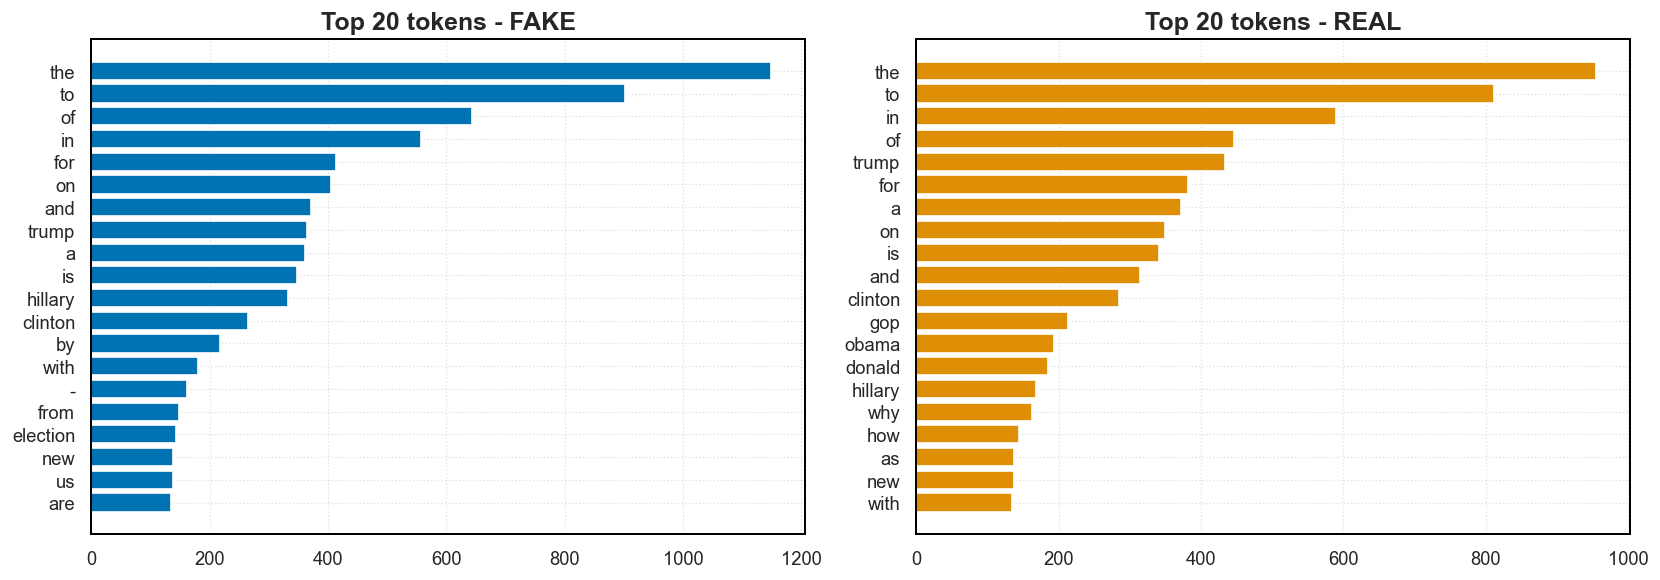

In [12]:
tokens_fake_flat = df_eda_fake["text"].str.lower().str.cat(sep=" ").split()
tokens_real_flat = df_eda_real["text"].str.lower().str.cat(sep=" ").split()

counter_fake = Counter(tokens_fake_flat)
counter_real = Counter(tokens_real_flat)

top20_fake = counter_fake.most_common(20)
top20_real = counter_real.most_common(20)

tokens_fake, counts_fake = zip(*top20_fake)
tokens_real, counts_real = zip(*top20_real)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(tokens_fake, counts_fake, color=PALETTE[0])
axes[0].set_title("Top 20 tokens - FAKE")
axes[0].invert_yaxis()

axes[1].barh(tokens_real, counts_real, color=PALETTE[1])
axes[1].set_title("Top 20 tokens - REAL")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig((FIGURE_DIR / "03_tokens_distribution_per_labels.png").as_posix())
plt.show()

Les top 20 des tokens les plus fréquents sont polués par les stopwords. On note toute de même que les titres `FAKE` utilisent davantage le prénom (Hillary) que le nom de famille (Clinton) et que réciproquement, les titres `REAL` utilisent davantage le nom de famille (Clinton) plutôt que le prénoms (Hillary).

Retirons les stopwords à l'exception des mots de négations pour essayer de déceler une tendance.

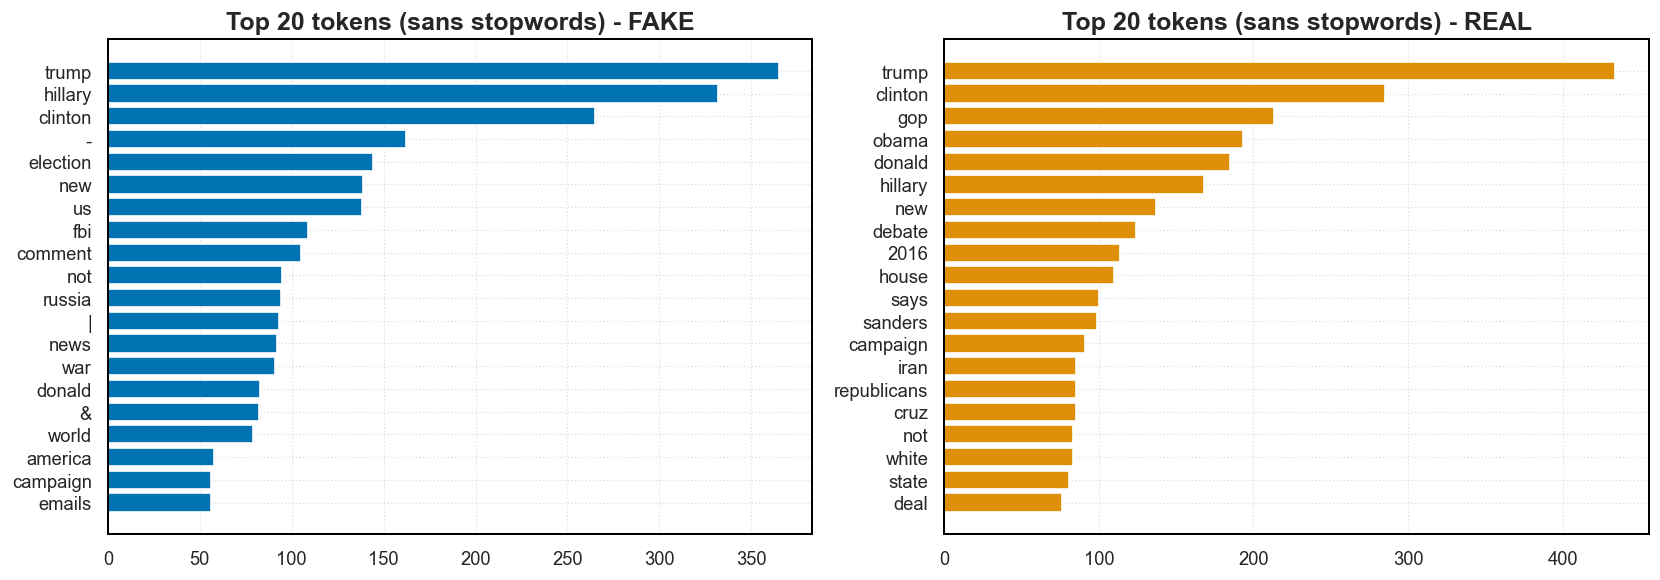

In [13]:
stop_words = set(nltk.corpus.stopwords.words("english"))
negations = {"not", "no", "never", "neither"}
stop_words = stop_words - negations

tokens_fake_flat_without_stopwords = [
    t for t in tokens_fake_flat if t not in stop_words
]
tokens_real_flat_without_stopwords = [
    t for t in tokens_real_flat if t not in stop_words
]

counter_fake_without_stopwords = Counter(tokens_fake_flat_without_stopwords)
counter_real_without_stopwords = Counter(tokens_real_flat_without_stopwords)

top20_fake_without_stopwords = counter_fake_without_stopwords.most_common(20)
top20_real_without_stopwords = counter_real_without_stopwords.most_common(20)

tokens_fake_without_stopwords, counts_fake_without_stopwords = zip(
    *top20_fake_without_stopwords
)
tokens_real_without_stopwords, counts_real_without_stopwords = zip(
    *top20_real_without_stopwords
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(
    tokens_fake_without_stopwords, counts_fake_without_stopwords, color=PALETTE[0]
)
axes[0].set_title("Top 20 tokens (sans stopwords) - FAKE")
axes[0].invert_yaxis()

axes[1].barh(
    tokens_real_without_stopwords, counts_real_without_stopwords, color=PALETTE[1]
)
axes[1].set_title("Top 20 tokens (sans stopwords) - REAL")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(
    (FIGURE_DIR / "04_tokens_distribution_per_labels_without_stopwords.png").as_posix()
)
plt.show()

* Dans les titres FAKE, on note par exemple la forte présence des mots *us* qui permet d'inclure le lecteur, des mots *fbi*, *russia*, *war*, *world* ou *america* qui peuvent être des tokens génériques ou sensationnalistes.
* Dans les titres REAL, on note la forte présence du token *2016* qui donne un contexte temporel, des mots *gop*, *dabate*, *white*, *house*, *républicans* ou *state* qui peuvent être des tokens plus journalistiques ou institutionnels.

Nombre total de tokens : 13667
Nombre de tokens communs : 3128
Nombre de tokens uniquement dans les titres FAKE : 6254
Nombre de tokens uniquement dans les titres REAL : 4285


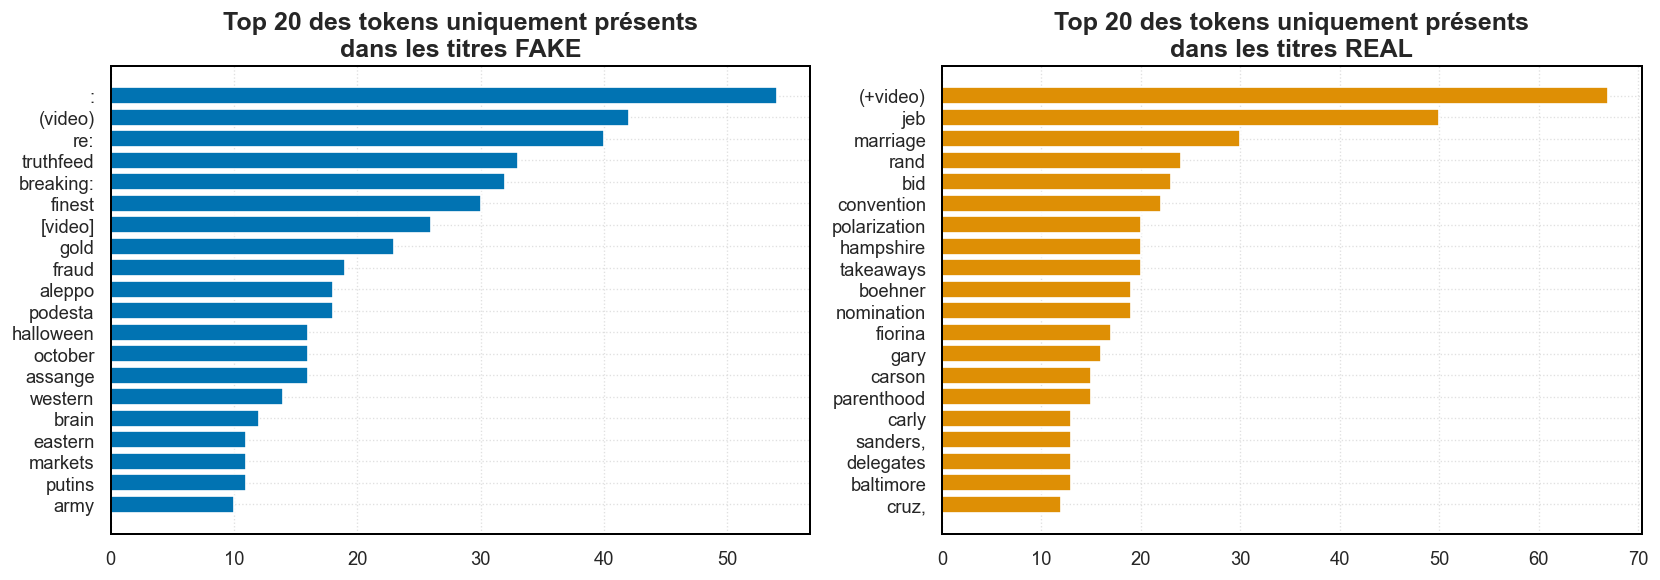

In [14]:
unique_tokens_fake = set(tokens_fake_flat)
unique_tokens_real = set(tokens_real_flat)

unique_tokens_union = unique_tokens_fake | unique_tokens_real
unique_tokens_intersection = unique_tokens_fake & unique_tokens_real
unique_tokens_fake_without_intersection = (
    unique_tokens_fake - unique_tokens_intersection
)
unique_tokens_real_without_intersection = (
    unique_tokens_real - unique_tokens_intersection
)


print(f"Nombre total de tokens : {len(unique_tokens_union)}")
print(f"Nombre de tokens communs : {len(unique_tokens_intersection)}")
print(
    f"Nombre de tokens uniquement dans les titres FAKE : {len(unique_tokens_fake_without_intersection)}"
)
print(
    f"Nombre de tokens uniquement dans les titres REAL : {len(unique_tokens_real_without_intersection)}"
)

counter_fake_unique = deepcopy(counter_fake)
counter_real_unique = deepcopy(counter_real)
for token in list(unique_tokens_intersection):
    counter_fake_unique.pop(token)
    counter_real_unique.pop(token)

top10_fake_unique = counter_fake_unique.most_common(20)
top10_real_unique = counter_real_unique.most_common(20)

words_fake_unique, counts_fake_unique = zip(*top10_fake_unique)
words_real_unique, counts_real_unique = zip(*top10_real_unique)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(words_fake_unique, counts_fake_unique, color=PALETTE[0])
axes[0].set_title("Top 20 des tokens uniquement présents\ndans les titres FAKE")
axes[0].invert_yaxis()

axes[1].barh(words_real_unique, counts_real_unique, color=PALETTE[1])
axes[1].set_title("Top 20 des tokens uniquement présents\ndans les titres REAL")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig((FIGURE_DIR / "05_unique_tokens_distribution_per_labels.png").as_posix())
plt.show()

* Pour les titres `FAKE`, on remarque la forte présence de format *(video)*, *re:*, *breaking:* ou *[video]*, la forte présence de *truthfeed* qui est un site douteux, la forte présence de mots pouvant appartenir à un champ lexical sensationnel comme *gold*, *fraud* ou encore *brain*.
* Pour les titres `REAL`, on remarque la forte présence d'arteur politique comme *jeb*, *rand*, *florina*, *gary*, *carson*, de processus démocratique comme *convention*, *nomination* ou *delegates* et des thèmes sociopolitiques comme *marriage*, *polarization* ou *nomination*. Le ton est clairement journalistique.

In [15]:
uncertain_words = {"could", "might", "reportedly", "claims", "allegedly"}


def is_ambiguous(title: str) -> bool:
    words = set(title.lower().split())
    return len(words & uncertain_words) > 0 and len(words) < 15


df_eda["is_ambiguous"] = df_eda["text"].apply(is_ambiguous)
ambiguous_titles = df_eda[df_eda["is_ambiguous"]][["text", "label"]]

print("Titres ambigus :")
print(
    f"  Texte : {ambiguous_titles.loc[273, 'text']} | label : {ambiguous_titles.loc[273, 'label']}"
)
print(
    f"  Texte : {ambiguous_titles.loc[974, 'text']} | label : {ambiguous_titles.loc[447, 'label']}"
)
print(
    f"  Texte : {ambiguous_titles.loc[498, 'text']} | label : {ambiguous_titles.loc[463, 'label']}"
)

Titres ambigus :
  Texte : Yes, Ted Cruz could win | label : 1
  Texte : The Sex Scandal That Could Change The Election | label : 0
  Texte : A report said Trump's donations to vets might be shady. His response was predictable. | label : 0


Les titres ambigus posent problème parce qu’ils ne ressemblent ni clairement à des titres FAKE ni à des titres REAL. Ils peuvent mélanger des éléments crédibles avec des formulations floues, ou encore des champs lexicaux opposés. Ces titres ambigus diminuent la séparabilité des classes.

## Partie 2 — Nettoyage et prétraitement

### 2.1 Pipeline de nettoyage

In [16]:
nlp = spacy.load("en_core_web_sm")

stop_words = set(nltk.corpus.stopwords.words("english"))
negations = {"not", "no", "never", "neither"}
stop_words = stop_words - negations

contractions = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "can't": "can not",
    "couldn't": "could not",
    "won't": "will not",
    "wouldn't": "would not",
    "shouldn't": "should not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "i'm": "i am",
    "you're": "you are",
    "he's": "he is",
    "she's": "she is",
    "it's": "it is",
    "we're": "we are",
    "they're": "they are",
    "i've": "i have",
    "you've": "you have",
    "we've": "we have",
    "they've": "they have",
    "i'll": "i will",
    "you'll": "you will",
    "he'll": "he will",
    "she'll": "she will",
    "we'll": "we will",
    "they'll": "they will",
    "there's": "there is",
    "that's": "that is",
}

DOMAIN_PATTERN = re.compile(
    r"\b(?:[a-z0-9-]+\.)+(?:org|net|info|co|io|gov|edu|uk|us|biz|online|site)\b"
)

TLD_PATTERN = re.compile(r"\.(com|org|net|info|co|io|gov|edu|uk|us|biz|online|site)\b")

CONTRACTION_PATTERN = re.compile(
    r"\b(" + "|".join(map(re.escape, contractions.keys())) + r")\b"
)


def expand_contractions(text: str) -> str:
    return CONTRACTION_PATTERN.sub(lambda x: contractions[x.group()], text)


def clean_title(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = DOMAIN_PATTERN.sub("", text)
    text = TLD_PATTERN.sub("", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\b\d+\b", "", text)
    text = expand_contractions(text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    doc = nlp(" ".join(tokens))
    lemmas = [token.lemma_ for token in doc]
    lemmas = [w for w in lemmas if len(w) >= 2]
    return " ".join(lemmas)


df["text_cleaned"] = df["text"].apply(clean_title)
df.head()

,text,label,text_cleaned
0,You Can Smell Hillarys Fear,0,smell hillarys fear
1,Watch The Exact Moment Paul Ryan Committed Pol...,0,watch exact moment paul ryan commit political ...
2,Kerry to go to Paris in gesture of sympathy,1,kerry go paris gesture sympathy
3,Bernie supporters on Twitter erupt in anger ag...,0,bernie supporter twitter erupt anger dnc try warn
4,The Battle of New York: Why This Primary Matters,1,battle new york primary matter


On ne supprime pas les mots "not", "no", "never", "neither" car ils servent à indiquer le caractère négatif d'une phrase.

### 2.2 Mesure de l'impact du nettoyage

In [17]:
df_eda["text_cleaned"] = df["text_cleaned"]
df_eda["tokens_cleaned"] = df_eda["text_cleaned"].str.split()
df_eda["length_cleaned"] = df_eda["tokens_cleaned"].apply(
    lambda list_tokens: len(list_tokens)
)

In [18]:
tokens_flat = df_eda["text"].str.lower().str.cat(sep=" ").split()
tokens_cleaned_flat = df_eda["text_cleaned"].str.lower().str.cat(sep=" ").split()

counter = Counter(tokens_flat)
counter_cleaned = Counter(tokens_cleaned_flat)

print(f"Nombre de tokens avant nettoyage : {len(counter)}")
print(f"Nombre de tokens après nettoyage : {len(counter_cleaned)}")
print(
    f"Différence du nombre de tokens avant et après nettoyage : {len(counter) - len(counter_cleaned)}"
)

Nombre de tokens avant nettoyage : 13667
Nombre de tokens après nettoyage : 7924
Différence du nombre de tokens avant et après nettoyage : 5743


In [19]:
length = df_eda["length"]
length_cleaned = df_eda["length_cleaned"]
length_difference = length - length_cleaned

print(
    f"Nombre moyenne de tokens par titre avant nettoyage : {length.mean():.2f} (+/- {length.std():.2f})"
)
print(
    f"Nombre moyenne de tokens par titre après nettoyage : {length_cleaned.mean():.2f} (+/- {length_cleaned.std():.2f})"
)
print(
    f"Réduction moyenne du nombre de token par titre : {length_difference.mean():.2f} (+/- {length_difference.std():.2f})"
)

Nombre moyenne de tokens par titre avant nettoyage : 10.45 (+/- 3.94)
Nombre moyenne de tokens par titre après nettoyage : 7.44 (+/- 2.72)
Réduction moyenne du nombre de token par titre : 3.01 (+/- 2.15)


In [20]:
mask = (
    (df["text_cleaned"].str.strip() != "")
    & (df["text_cleaned"].str.strip().str.lower() != "null")
    & (df["text_cleaned"].str.strip().str.lower() != "none")
    & (df["text_cleaned"] is not None)
)

print(f"Nombre de ligne vide : {len(df[~mask])}")

print()
print(df[~mask].head())
df_cleaned = df[mask]

Nombre de ligne vide : 2

         text  label text_cleaned
3456        :      0             
6037  C     !      0             


Je supprime les lignes vides après nettoyage. Ces lignes n'apportent pas d'information.

Pourquoi la conservation des mots de négation est-elle particulièrement importante dans un contexte de détection de désinformation ? Donnez deux exemples concrets tirés du corpus.

* Il est crutial de conserver les mots de négation car il change le sens de la phrase. "Brexit Encourages UK to Trade With Non-EU States, Including Russia" et "Brexit Does Not Encourages UK to Trade With Non-EU States, Including Russia" sont en opposition.

* De plus ils peuvent indiquer une constestation. Par exemple dans la phrase "Donald Trump Is Changing His Campaign Slogan to Prove He’s Not Racist", la négation montre que Donald Trump contest l'idée qu'il soit raciste.

## Partie 3 — Représentation vectorielle

### 3.1 Vectorisation TF-IDF

In [21]:
texts = df_cleaned[["text", "text_cleaned"]]
labels = df_cleaned["label"]

texts_train, texts_test, labels_train, labels_test = train_test_split(
    texts, labels, stratify=labels, test_size=0.2, random_state=RANDOM_STATE
)

texts_train_cleaned = texts_train["text_cleaned"]
texts_test_cleaned = texts_test["text_cleaned"]

texts_train_raw = tf.convert_to_tensor(texts_train["text"])
texts_test_raw = tf.convert_to_tensor(texts_test["text"])

print(f"Nombre total de titres : {len(texts)}")
print(
    f"Nombre total de titres dans le jeu d'entrainement : {len(texts_train)} ({len(texts_train) / len(texts) * 100:.0f}%)"
)
print(
    f"Nombre total de titres dans le jeu de test : {len(texts_test)} ({len(texts_test) / len(texts) * 100:.0f}%)"
)

print()
print(
    f"Répartition des labels dans le jeu de données : FAKE {(1 - labels.sum() / len(labels)) * 100:.0f}% - REAL {labels.sum() / len(labels) * 100:.0f}%"
)
print(
    f"Répartition des labels dans le jeu d'entrainement : FAKE {(1 - labels_train.sum() / len(labels_train)) * 100:.0f}% - REAL {labels_train.sum() / len(labels_train) * 100:.0f}%"
)
print(
    f"Répartition des labels dans le jeu de test : FAKE {(1 - labels_test.sum() / len(labels_test)) * 100:.0f}% - REAL {labels_test.sum() / len(labels_test) * 100:.0f}%"
)

Nombre total de titres : 6333
Nombre total de titres dans le jeu d'entrainement : 5066 (80%)
Nombre total de titres dans le jeu de test : 1267 (20%)

Répartition des labels dans le jeu de données : FAKE 50% - REAL 50%
Répartition des labels dans le jeu d'entrainement : FAKE 50% - REAL 50%
Répartition des labels dans le jeu de test : FAKE 50% - REAL 50%


In [22]:
MAX_FEATURES = 3000

tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True,
)

texts_train_vectorized = tfidf.fit_transform(texts_train_cleaned, labels_train)
texts_test_vectorized = tfidf.transform(texts_test_cleaned)

print(f"Vocabulaire : {len(tfidf.get_feature_names_out())} mots uniques")

Vocabulaire : 3000 mots uniques


In [23]:
joblib.dump(tfidf, TF_IDF_VECTORIZER_FILE.as_posix())
print(f"Vectorizer enregistré : path={TF_IDF_VECTORIZER_FILE}")

Vectorizer enregistré : path=C:\Users\Administrateur\Documents\DESSAUX_Damien_ECF4\models\tf_idf_vectorizer.pkl


### 3.2 Embedding avec TensorFlow

In [24]:
MAX_TOKENS = 5000
OUTPUT_SEQUENCE_LENGTH = 30

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    ngrams=(1, 2),
    output_mode="int",
    output_sequence_length=OUTPUT_SEQUENCE_LENGTH,
    standardize="lower_and_strip_punctuation",
    split="whitespace",
)

vectorizer.adapt(texts_train_raw)

texts_train_seq = vectorizer(texts_train_raw)
texts_test_seq = vectorizer(texts_test_raw)

print(f"Dimensions de texts_train_seq: {texts_train_seq.shape}")
print(f"Dimensions de texts_test_seq: {texts_test_seq.shape}")
print(f"Vocabulaire : {len(vectorizer.get_vocabulary())} mots uniques")

Dimensions de texts_train_seq: (5066, 30)
Dimensions de texts_test_seq: (1267, 30)
Vocabulaire : 5000 mots uniques


Quelle différence fondamentale y a-t-il entre un vecteur TF-IDF et un vecteur d'embedding appris ? Laquelle de ces deux représentations est capable de capturer que `misleading` et `deceptive` sont sémantiquement proches ? Justifiez.

* TF-IDF encode uniquement la présence d'un mot et ne contient aucune information de similarité sémantique entre les mots. Les mots "misleading" et "deceptive" sont des dimensions indépendantes, même s'ils sont synonymes.

* Les vecteurs embeddings sont appris à partir des contextes d'apparition des mots. Des mots apparaissant dans des contextes similaires ont des vecteurs proches. Ainsi, "misleading" et "deceptive" deviennent proches dans l’espace vectoriel si leurs contextes d’usage est proche.

In [25]:
label_encoder = LabelEncoder()
labels_train_encoded = label_encoder.fit_transform(labels_train)
labels_test_encoded = label_encoder.transform(labels_test)

## Partie 4 — Modélisation

### 4.1 Modèle baseline — réseau dense sur TF-IDF

In [26]:
def create_model_dense() -> keras.Sequential:
    model = keras.Sequential(
        [
            layers.Input(shape=(MAX_FEATURES,), name="input"),
            layers.Dense(256, activation="relu", name="hidden1"),
            layers.Dropout(0.4, name="dropout1"),
            layers.Dense(128, activation="relu", name="hidden2"),
            layers.Dropout(0.3, name="dropout2"),
            layers.Dense(1, activation="sigmoid", name="output"),
        ],
        name="dense",
    )

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return model


model_dense = create_model_dense()
model_dense.summary()

Model: "dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 256)            │       768,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801,281 (3.06 MB)

 Trainable params: 801,281 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
def create_early_stopping():
    return keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    )


def create_reduce_lr_on_plateau():
    return keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    )


def create_model_checkpoint(filepath: Path):
    return keras.callbacks.ModelCheckpoint(
        filepath=filepath.as_posix(),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    )


start_fit_model_dense = time.time()
history_model_dense = model_dense.fit(
    texts_train_vectorized,
    labels_train_encoded,
    batch_size=64,
    epochs=30,
    validation_split=0.15,
    callbacks=[
        create_reduce_lr_on_plateau(),
        create_early_stopping(),
        create_model_checkpoint(MODEL_DENSE_FILE),
    ],
    verbose=1,
)
end_fit_model_dense = time.time()

Epoch 1/30
58/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5682 - loss: 0.6872
Epoch 1: val_accuracy improved from None to 0.77368, saving model to C:/Users/Administrateur/Documents/DESSAUX_Damien_ECF4/models/model_dense.keras

Epoch 1: finished saving model to C:/Users/Administrateur/Documents/DESSAUX_Damien_ECF4/models/model_dense.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6677 - loss: 0.6555 - val_accuracy: 0.7737 - val_loss: 0.5376 - learning_rate: 0.0010
Epoch 2/30
55/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8261 - loss: 0.4280
Epoch 2: val_accuracy improved from 0.77368 to 0.79211, saving model to C:/Users/Administrateur/Documents/DESSAUX_Damien_ECF4/models/model_dense.keras

Epoch 2: finished saving model to C:/Users/Administrateur/Documents/DESSAUX_Damien_ECF4/models/model_dense.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8535 - loss: 0.3592 - val_accuracy: 0.7921 - val_loss: 0.4790 - learning_rate: 0.0010
Epoch 3/30
53/68 ━━━━━━━━━━

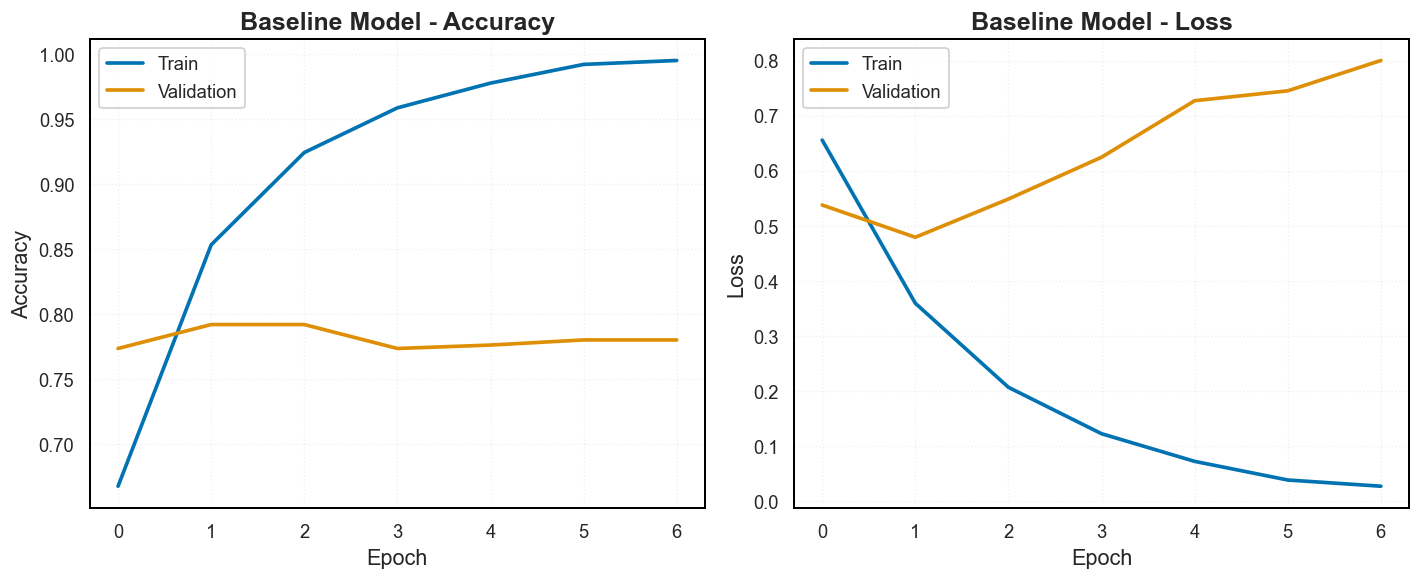

In [28]:
def plot_history(history, model_name: str, savepath: Path) -> None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy
    ax1.plot(history.history["accuracy"], label="Train")
    ax1.plot(history.history["val_accuracy"], label="Validation")
    ax1.set_title(f"{model_name} - Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss
    ax2.plot(history.history["loss"], label="Train")
    ax2.plot(history.history["val_loss"], label="Validation")
    ax2.set_title(f"{model_name} - Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(savepath.as_posix())
    plt.show()


plot_history(
    history_model_dense,
    "Baseline Model",
    FIGURE_DIR / "06_history_model_dense.png",
)

Les courbes de loss et d'accuracy montre que le modèle sur-apprends. Pour corriger le sur-apprentissage, on peut réduire la taille des couches (256 -> 128), augmenter le dropout (0.4 -> 0.5), ajouter des couches de normalisation (BatchNormalisation) ou augmenter le nombre de données. Cependant je pense qu'il sera difficile d'augmenter l'accuracy avec une vectorialisation TF-IDF.

### 4.2 Modèle avec embeddings appris — architecture séquentielle

In [29]:
def create_model_bidirectional_lstm(
    vectorizer: tf.keras.layers.TextVectorization,
) -> keras.Sequential:
    vocab_size = len(vectorizer.get_vocabulary())

    model = keras.Sequential(
        [
            keras.Input(shape=(1,), dtype=tf.string),
            vectorizer,
            layers.Embedding(input_dim=vocab_size, output_dim=64, mask_zero=True),
            layers.Bidirectional(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(1, activation="sigmoid"),
        ]
    )

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return model


model_bidirectional_lstm = create_model_bidirectional_lstm(vectorizer)
model_bidirectional_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 30)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 30, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,369 (1.50 MB)

 Trainable params: 394,369 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
start_fit_model_bidirectional_lstm = time.time()
history_model_bidirectional_lstm = model_bidirectional_lstm.fit(
    texts_train_raw,
    labels_train_encoded,
    batch_size=64,
    epochs=30,
    validation_split=0.15,
    callbacks=[
        create_reduce_lr_on_plateau(),
        create_early_stopping(),
        create_model_checkpoint(MODEL_BIDIRECTIONAL_LSTM_FILE),
    ],
    verbose=1,
)
end_fit_model_bidirectional_lstm = time.time()

Epoch 1/30
67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5402 - loss: 0.6838
Epoch 1: val_accuracy improved from None to 0.75000, saving model to C:/Users/Administrateur/Documents/DESSAUX_Damien_ECF4/models/model_bidirectional_lstm.keras

Epoch 1: finished saving model to C:/Users/Administrateur/Documents/DESSAUX_Damien_ECF4/models/model_bidirectional_lstm.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.6075 - loss: 0.6504 - val_accuracy: 0.7500 - val_loss: 0.5256 - learning_rate: 0.0010
Epoch 2/30
67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8100 - loss: 0.4374
Epoch 2: val_accuracy improved from 0.75000 to 0.82105, saving model to C:/Users/Administrateur/Documents/DESSAUX_Damien_ECF4/models/model_bidirectional_lstm.keras

Epoch 2: finished saving model to C:/Users/Administrateur/Documents/DESSAUX_Damien_ECF4/models/model_bidirectional_lstm.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8451 - loss: 0.3753 - val_accuracy: 0.8211 - val_loss: 0.

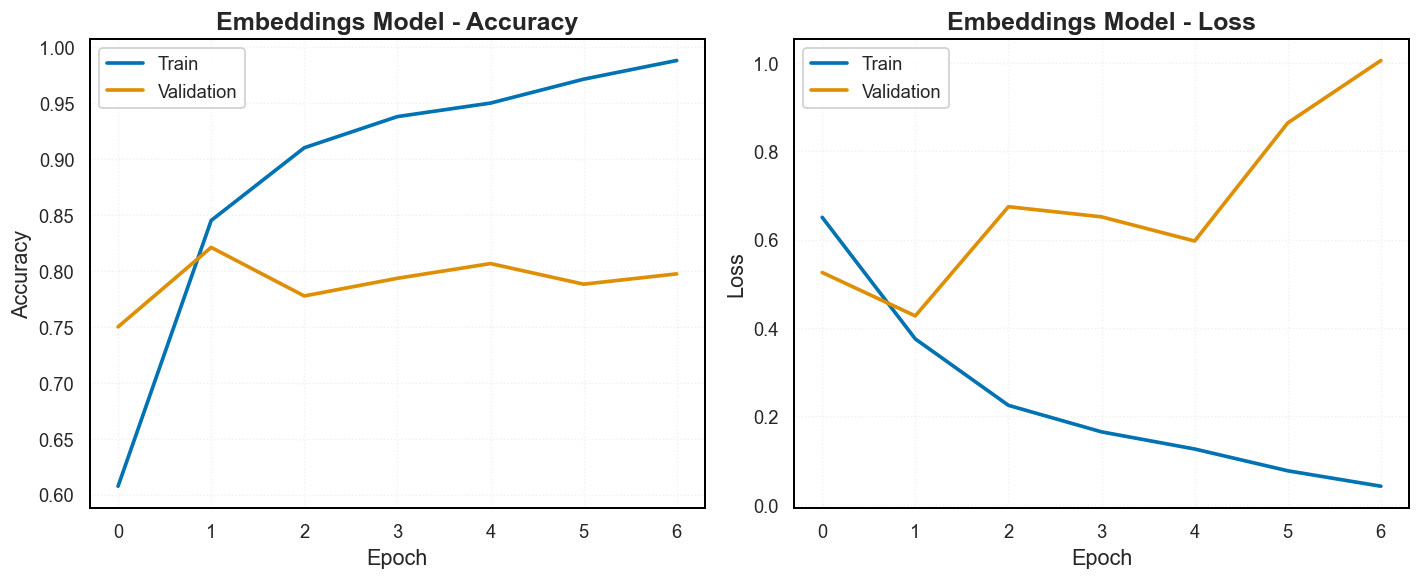

In [31]:
plot_history(
    history_model_bidirectional_lstm,
    "Embeddings Model",
    FIGURE_DIR / "07_history_model_bidirectional_lstm.png",
)

Les courbes de loss et d'accuracy montre que le modèle sur-apprends. Je pense qu'il sera difficile d'augmenter l'accuracy avec un jeu de données aussi petit, la couche d'embeddings ne semble pas avoir suffisamment de données pour construire une représentation sémantique correcte des tokens.

### 4.3 Comparaison des deux architectures

In [32]:
def predict_with_timing(model, X, y, threshold=0.5):
    start_time = time.time()
    y_proba = model.predict(X)
    end_time = time.time()

    y_pred = (y_proba > threshold).astype(int)

    inference_time_per_sample = (end_time - start_time) / len(y)

    return {
        "y_proba": y_proba,
        "y_pred": y_pred,
        "inference_time": inference_time_per_sample,
    }


def compute_classification_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy (test)": accuracy_score(y_true, y_pred),
        "Precision - classe FAKE": precision_score(y_true, y_pred, pos_label=0),
        "Recall - classe FAKE": recall_score(y_true, y_pred, pos_label=0),
        "Precision - classe REAL": precision_score(y_true, y_pred, pos_label=1),
        "Recall - classe REAL": recall_score(y_true, y_pred, pos_label=1),
        "F1-score (macro)": f1_score(y_true, y_pred, average="macro"),
        "AUC-ROC": roc_auc_score(y_true, y_proba),
    }


def get_model_info(model, history, train_time):
    return {
        "Epochs effectifs (EarlyStopping)": len(history.epoch),
        "Nombre de paramètres entraînables": sum(
            tf.keras.backend.count_params(w) for w in model.trainable_weights
        ),
        "Temps d'entraînement (approx.)": train_time,
    }


def compare_models(models_config, y_true):
    """
    models_config: liste de dicts contenant:
        {
            "name": str,
            "model": keras model,
            "X_test": données de test,
            "history": history object,
            "train_time": float
        }
    """

    results = {}

    for config in models_config:
        name = config["name"]
        model = config["model"]
        X_test = config["X_test"]
        history = config["history"]
        train_time = config["train_time"]

        pred_results = predict_with_timing(model, X_test, y_true)

        metrics = compute_classification_metrics(
            y_true, pred_results["y_pred"], pred_results["y_proba"]
        )

        model_info = get_model_info(model, history, train_time)

        results[name] = {
            **metrics,
            **model_info,
            "Temps d'inférence (approx.)": pred_results["inference_time"],
        }

    df = pd.DataFrame(results)
    df.insert(0, "Critère", df.index)

    return df.reset_index(drop=True)


models_config = [
    {
        "name": "Modèle Dense (TF-IDF)",
        "model": model_dense,
        "X_test": texts_test_vectorized,
        "history": history_model_dense,
        "train_time": end_fit_model_dense - start_fit_model_dense,
    },
    {
        "name": "Modèle LSTM Bidirectionnel (Embeddings)",
        "model": model_bidirectional_lstm,
        "X_test": texts_test_raw,
        "history": history_model_bidirectional_lstm,
        "train_time": end_fit_model_bidirectional_lstm
        - start_fit_model_bidirectional_lstm,
    },
]

df_models = compare_models(models_config, labels_test)
df_models.head(10)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


,Critère,Modèle Dense (TF-IDF),Modèle LSTM Bidirectionnel (Embeddings)
0,Accuracy (test),0.805051,0.800316
1,Precision - classe FAKE,0.782991,0.767606
2,Recall - classe FAKE,0.843602,0.860979
3,Precision - classe REAL,0.830769,0.842011
4,Recall - classe REAL,0.766562,0.739748
5,F1-score (macro),0.804771,0.799595
6,AUC-ROC,0.886519,0.888471
7,Epochs effectifs (EarlyStopping),7.000000,7.000000
8,Nombre de paramètres entraînables,801281.000000,394369.000000
9,Temps d'entraînement (approx.),3.234036,12.807988


Lequel des deux modèles recommanderiez-vous pour une mise en production ? Justifiez votre choix en tenant compte à la fois des performances et des contraintes opérationnelles (temps de réponse, maintenance, volume de données).

Les deux modèles présentent de l'overfitting. L'accuracy, le F1-score macro et l'AUC-ROC sont très proches. L'objectif ici est de classer correctement l'ensemble des articles, on s'oriente donc vers une métrique globale comme le F1-score macro. Si on cherchait à réduire les faux-positifs, c'est à dire les titres qui sont classé comme REAL alors qu'il sont FAKE, on s'orienterait vers un modèle avec une bonne precission de la classe REAL. Le modèle Dense (TF-IDF) est un peu plus équilibré sur la détection des deux classes et son temps d'entraînement est inférieur, je recommande donc ce modèle.

Pour augmenter l'accuracy, on pourrait se diriger vers des modèles pré-entraîné comme FastText ou RoBERTa avec fine-tunning sur classification binaire.

## Partie 5 — Évaluation approfondie

### 5.1 Analyse des performances du meilleur modèle

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


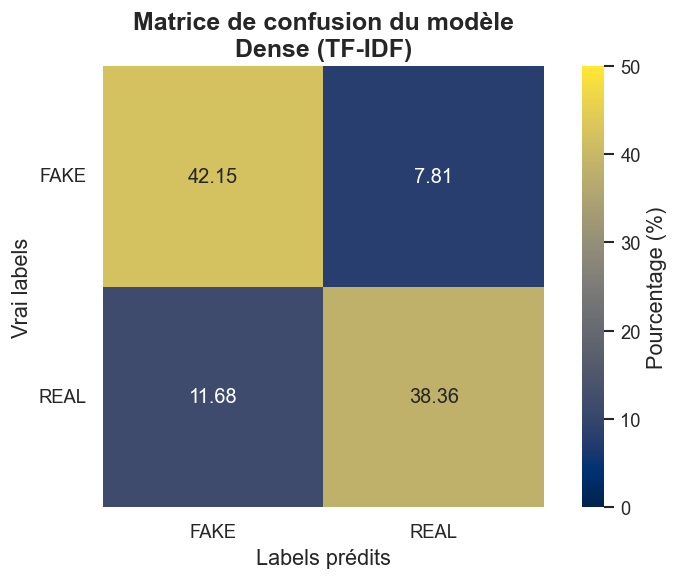

In [33]:
labels_names = ["FAKE", "REAL"]

predict_dense = predict_with_timing(model_dense, texts_test_vectorized, labels_test)
labels_pred_dense = predict_dense["y_pred"]
labels_proba_dense = predict_dense["y_proba"]

cm = confusion_matrix(labels_test, labels_pred_dense)
cm_percent = cm / cm.sum().sum() * 100

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2f",
    cmap="cividis",
    square=True,
    vmin=0,
    vmax=50,
    cbar_kws={"label": "Pourcentage (%)"},
)

plt.xlabel("Labels prédits")
plt.xticks(np.arange(0.5, 2.5, 1), labels_names, rotation=0)
plt.ylabel("Vrai labels")
plt.yticks(np.arange(0.5, 2.5, 1), labels_names, rotation=0)
plt.title("Matrice de confusion du modèle\nDense (TF-IDF)")

plt.tight_layout()
plt.savefig((FIGURE_DIR / "08_confusion_matrix_model_dense").as_posix())
plt.show()

On rappelle que les titres sont équirépartis entre les classes FAKE et REAL.
* Environ 42% des titres FAKE ont été bien classés, soit environ 8% de faux-positifs.
* Environ 38% des titres REAL ont été bien classés, soit envriron 12% de faux-négatifs.

In [34]:
print("Rapport de classification du modèle Dense :")
print(classification_report(labels_test, labels_pred_dense))

Rapport de classification du modèle Dense :
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       633
           1       0.83      0.77      0.80       634

    accuracy                           0.81      1267
   macro avg       0.81      0.81      0.80      1267
weighted avg       0.81      0.81      0.80      1267



* Les classes étant équilibrées, les métriques accuracy ($\simeq 0.81$) et f1-score macro ($\simeq 0.80$) ne sont pas biaisées et montre que le modèle a une performance globale correcte.
* Le modèle détecte bien la classe FAKE (recall $\simeq 0.84$), mais a tendance à prédire cette classe à tord (precision $\simeq 0.78$).
* Le modèle détecte moins bien la classe REAL (recall $\simeq 0.77$) et ses prédiction pour cette classe sont plus fiables (precision $\simeq 0.83$).
* En conclusion, le modèle est correct mais il détecte mieux les titres FAKE que les titres REAL, la modification du seuil de décision pourrait corriger ce déséquilibre de prédiction.

In [35]:
fpr, tpr, thresholds = roc_curve(labels_test, labels_proba_dense)
auc = roc_auc_score(labels_test, labels_proba_dense)

print(f"AUC : {auc}")

AUC : 0.8865188053483237


In [36]:
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]

print("Seuil optimal : ", optimal_threshold)

Seuil optimal :  0.5411010980606079


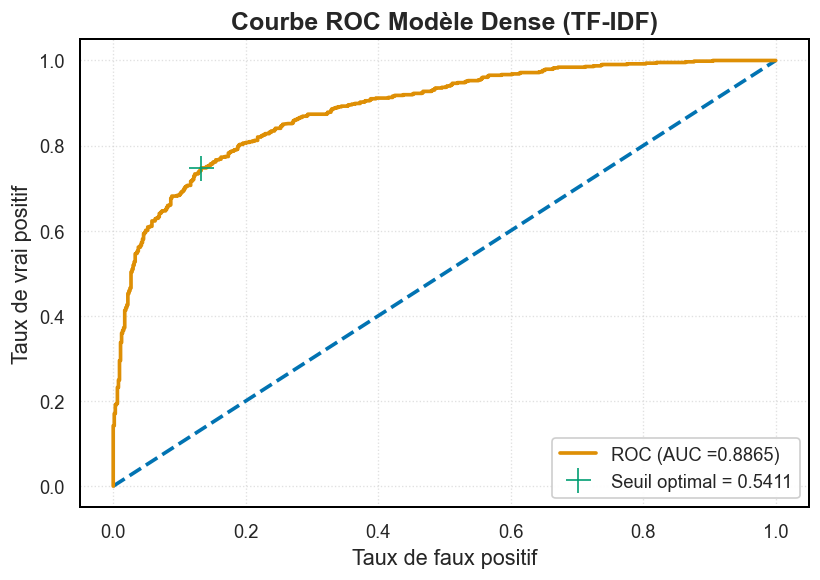

In [37]:
fig, axes = plt.subplots(1, 1, figsize=(7, 5))

axes.plot([0, 1], [0, 1], "--", color=PALETTE[0])
axes.plot(fpr, tpr, label=f"ROC (AUC ={auc:.4f})", color=PALETTE[1])
axes.plot(
    fpr[optimal_idx],
    tpr[optimal_idx],
    "+",
    markersize=15,
    label=f"Seuil optimal = {optimal_threshold:.4f}",
    color=PALETTE[2],
)

axes.set_title("Courbe ROC Modèle Dense (TF-IDF)")
axes.set_xlabel("Taux de faux positif")
axes.set_ylabel("Taux de vrai positif")
axes.legend()

plt.tight_layout()
plt.savefig((FIGURE_DIR / "09_roc_curve_model_dense").as_posix())
plt.show()

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


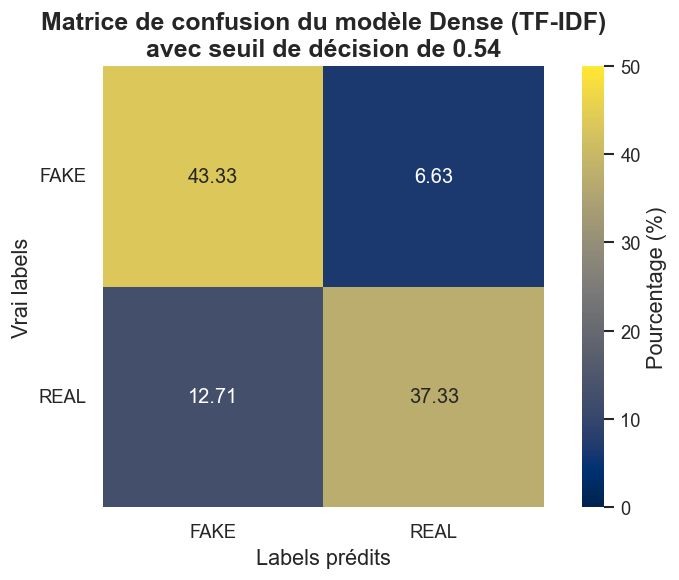

In [38]:
predict_dense_optimal_threshold = predict_with_timing(
    model_dense, texts_test_vectorized, labels_test, threshold=optimal_threshold
)
labels_pred_dense_optimal_threshold = predict_dense_optimal_threshold["y_pred"]
labels_proba_dense_optimal_threshold = predict_dense_optimal_threshold["y_proba"]

cm_optimal_threshold = confusion_matrix(
    labels_test, labels_pred_dense_optimal_threshold
)
cm_percent_optimal_threshold = (
    cm_optimal_threshold / cm_optimal_threshold.sum().sum() * 100
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_percent_optimal_threshold,
    annot=True,
    fmt=".2f",
    cmap="cividis",
    square=True,
    vmin=0,
    vmax=50,
    cbar_kws={"label": "Pourcentage (%)"},
)

plt.xlabel("Labels prédits")
plt.xticks(np.arange(0.5, 2.5, 1), labels_names, rotation=0)
plt.ylabel("Vrai labels")
plt.yticks(np.arange(0.5, 2.5, 1), labels_names, rotation=0)
plt.title(
    f"Matrice de confusion du modèle Dense (TF-IDF)\navec seuil de décision de {optimal_threshold:.2f}"
)

plt.tight_layout()
plt.savefig(
    (FIGURE_DIR / "10_confusion_matrix_model_dense_optimal_threshold").as_posix()
)
plt.show()

Avec un seuil de décision de $\simeq 0.54$, le modèle semble mieux détecter la classe FAKE et moins bien détecter la classe REAL, diminuant le nombre de faux-positifs et augmentant le nombre de faux-négatifs.

In [39]:
print(
    f"Rapport de classification du modèle Dense avec seuil de décision de {optimal_threshold} :"
)
print(classification_report(labels_test, labels_pred_dense_optimal_threshold))

Rapport de classification du modèle Dense avec seuil de décision de 0.5411010980606079 :
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       633
           1       0.85      0.75      0.79       634

    accuracy                           0.81      1267
   macro avg       0.81      0.81      0.81      1267
weighted avg       0.81      0.81      0.81      1267



* La modification du seuil de décision a permis d'avoir un modèle globalement meilleur, gain de 0.01 en f1-score macro.
* Le modèle détecte mieux la classe FAKE (+0.03 recall) mais les titres classés comme FAKE ont une moins grande probabilité d'être vraiment FAKE (-0.01 precision).
* A l'inverse le modèle détecte moins bien la classe REAL (-0.02 recall) mais les titres classés comme REAL ont une plus grande probabilité d'être vraiement REAL (+0.02 precision).

### 5.2 Analyse des erreurs

In [40]:
predictions = texts_test.copy()
predictions["label"] = labels_test
predictions["predict_label"] = labels_pred_dense_optimal_threshold.flatten()
predictions["probability"] = labels_proba_dense_optimal_threshold.flatten()

false_positive = predictions[
    (predictions["predict_label"] == 1) & (predictions["label"] == 0)
].sort_values("probability", ascending=False)
false_negative = predictions[
    (predictions["predict_label"] == 0) & (predictions["label"] == 1)
].sort_values("probability", ascending=True)

print("15 Faux-Positifs :")
print("  Probability | Text")
for text, proba in (
    false_positive[["text", "probability"]].head(15).itertuples(index=False)
):
    print(f"  {proba:<11.6f} | {text}")

print()
print("15 Faux-Négatifs :")
print("  Probability | Text")
for text, proba in (
    false_negative[["text", "probability"]].head(15).itertuples(index=False)
):
    print(f"  {proba:<11.6f} | {text}")

15 Faux-Positifs :
  Probability | Text
  0.977037    | Planned Parenthood: Abortion pill usage now rivals surgery
  0.972548    | Awesome Video Shows The REAL Donald Trump, Presidential Candidate
  0.970114    | A noun, a verb and Donald Trump: Rubio seeks to seize on Murphys flaw
  0.969745    | Saudis Foil ISIS Terror Attacks on Packed Stadium
  0.964274    | Comments circulating about the Republican presidential candidate
  0.962392    | Erdogan Checks in with Obama Before Bombing Syria
  0.950698    | Peaceful, sincerely, with grace: Paris attacks commemorated with floating lanterns
  0.941897    | Iran, Finland sign 4 MoUs in Tehran
  0.938376    | Washington's Embargo on Cuba Not Effective, Isolated US - White House
  0.937256    | Look out, Paul Ryan! Masochist Paul Nehlen is gunning for House speakership
  0.935420    | Canada and EU sign thoroughly undemocratic CETA trade deal
  0.918518    | Journalism Startup Newsbud Launches Critical 2nd Crowdfund - Richard Brandt
  0.9166

Quels patterns linguistiques communs observez-vous ? Le modèle semble-t-il sensible à certains mots ou structures de phrase ?

* Pour les faux-positifs, on relève des titres avec un ton non journalistique comme "Awesome Video Shows The REAL Donald Trump", des titres émotionnels comme "Look out, Paul Ryan!", "Peaceful, sincerely, with grace" ou "Masochist Paul Nehlen…", un champ lexical politique comme "Iran", "Cuba", "Saudis", "Erdogan".
* Pour les faux-négatifs, on relève des titres sobres comme "What 20,000 pages of hacked WikiLeaks emails teach us…" ou "Why Trump’s warning… isn’t credible", des titres courts et vagues comme "Life Among the Berned" ou "Here come the jobs, finally", des titres avec des chiffres comme "3 reasons Americans die sooner…".

Le modèle semble plutôt détecter le style d'écriture. Avec un modèle pré-entraîné comme RoBERTa on pourrait détecter plus finement le sens des phrases.

### 5.3 Robustesse

In [41]:
def predict_label(texts: list[str], vectoriser, model, threshold) -> tuple[int, float]:
    texts_clean = [clean_title(text) for text in texts]
    texts_vect = vectoriser.transform(texts_clean)
    labels_proba = model.predict(texts_vect)
    labels_pred = (labels_proba > threshold).astype(int)
    return labels_pred, labels_proba


new_texts = [
    "Scientists discover new treatment for common disease",
    "SHOCKING: Government hiding truth about water supply",
    "Local elections results announced in three counties",
    "You won't believe what this celebrity did last night",
    "Central bank raises interest rates by 0.25 points",
    "This one weird trick cures all allergies naturally",
    "Parliament votes on new environmental legislation",
    "Doctors don't want you to know this secret remedy",
    "Tech company reports quarterly earnings below forecast",
    "EXCLUSIVE: Famous actor reveals hidden agenda of elites",
]

new_labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

labels_pred_new, labels_proba_new = predict_label(
    new_texts, tfidf, model_dense, optimal_threshold
)

print("Vrai label | Label prédit | Probabilité | Text")
for label, label_pred, label_proba, text in zip(
    new_labels, labels_pred_new.flatten(), labels_proba_new.flatten(), new_texts
):
    print(
        f"{labels_names[label]:<10} | {labels_names[label_pred]:<12} | {label_proba:<11.6f} | {text}"
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Vrai label | Label prédit | Probabilité | Text
REAL       | FAKE         | 0.196686    | Scientists discover new treatment for common disease
FAKE       | FAKE         | 0.015276    | SHOCKING: Government hiding truth about water supply
REAL       | FAKE         | 0.418088    | Local elections results announced in three counties
FAKE       | REAL         | 0.547704    | You won't believe what this celebrity did last night
REAL       | FAKE         | 0.293272    | Central bank raises interest rates by 0.25 points
FAKE       | FAKE         | 0.023323    | This one weird trick cures all allergies naturally
REAL       | FAKE         | 0.249061    | Parliament votes on new environmental legislation
FAKE       | FAKE         | 0.146686    | Doctors don't want you to know this secret remedy
REAL       | FAKE         | 0.087772    | Tech company reports quarterly earnings below forecast
FAKE       | FAKE         | 0.261669    | EXCLUSIVE: Famous actor reve

Les prédictions vous semblent-elles cohérentes ? Y a-t-il des titres pour lesquels le modèle se trompe manifestement ou hésite ?

* FAKE correctement détectés :
  * SHOCKING: Government hiding truth about water supply
  * You won't believe what this celebrity did last night
  * This one weird trick cures all allergies naturally
  * Doctors don't want you to know this secret remedy
  * EXCLUSIVE: Famous actor reveals hidden agenda of elites

* Faux négatifs :
  * Local elections results announced in three counties
  * Scientists discover new treatment for common disease
  * Central bank raises interest rates by 0.25 points
  * Tech company reports quarterly earnings below forecast

* Faux positifs :
  * You won't believe what this celebrity did last night

Le modèle a beaucoup de difficulté à détecter les titre REAL et a tendance à classer les titre en FAKE.

### Confidence

Pour calculer la confiance j'utilise la fonction $c$ qui a $p \in [0,1]$ associe $c(p)$ défini par :
$$
c(p) =
\begin{cases}
\dfrac{t - p}{t} & \text{si } p \leq t, \\
\dfrac{p - t}{1 - t} & \text{sinon},
\end{cases}
\quad \text{où } t \in ]0,1[ \text{ représente le seuil de décision}.
$$
Cette fonction sera utilisée dans l'API pour le calcule de la confiance : `api/utils/ml_model.py`.

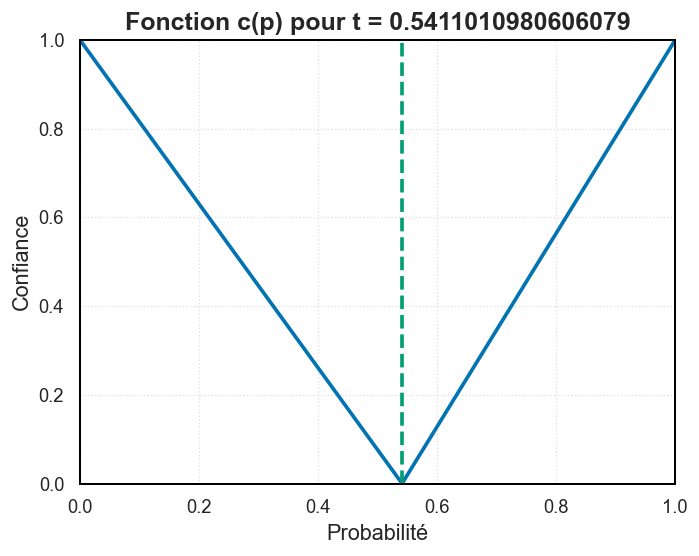

In [47]:
def c(p, t):
    return np.where(p <= t, (t - p) / t, (p - t) / (1 - t))


p = np.linspace(0, 1, 500)
c_values = c(p, optimal_threshold)

plt.figure()
plt.plot(p, c_values)
plt.axvline(optimal_threshold, linestyle="--", color=PALETTE[2])
plt.xlabel("Probabilité")
plt.xlim((0, 1))
plt.ylabel("Confiance")
plt.ylim((0, 1))
plt.title(f"Fonction c(p) pour t = {optimal_threshold}")
plt.show()